In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import os

# Load the dataset
df = pd.read_csv('../data/raw/load_forecasting_dataset_corrected.csv')
df.head()

Matplotlib is building the font cache; this may take a moment.


,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW)
0,1/1/2020 0:00,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,2,0,1,Summer,0,1599.342831
1,1/1/2020 0:15,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,2,0,1,Summer,0,1472.347140
2,1/1/2020 0:30,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,2,0,1,Summer,0,1629.537708
3,1/1/2020 0:45,31.046060,87.615995,2.539148,1.038103,336.407064,937.963002,468.038834,26.032137,2,0,1,Summer,1,1804.605971
4,1/1/2020 1:00,27.531693,79.709858,1.366819,4.201393,205.494256,934.477462,488.565716,27.079114,2,1,1,Summer,0,1453.169325


In [2]:
# 1. Feature Engineering: Handle Categorical 'Season'
df_processed = pd.get_dummies(df, columns=['Season'], prefix='Season')

# 2. Add 'is_weekend' (Sri Lankan context: Saturday=5, Sunday=6)
df_processed['is_weekend'] = df_processed['Day of Week'].apply(lambda x: 1 if x >= 5 else 0)

# 3. Define X and y (Drop Timestamp as we have Hour/Day/Month already)
X = df_processed.drop(['Timestamp', 'Load Demand (kW)'], axis=1)
y = df_processed['Load Demand (kW)']

# 4. Split data (70% Train, 15% Val, 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 5. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for the Front-End
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')

print("Preprocessing complete. Scaler saved.")

Preprocessing complete. Scaler saved.


In [3]:
# Initialize and train XGBoost
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=100
)

# Save the trained model for the Front-End
joblib.dump(model, '../models/trained_model.pkl')
print("Model trained and saved to models/trained_model.pkl")

[0]	validation_0-rmse:189.79658
[100]	validation_0-rmse:6.25097
[200]	validation_0-rmse:6.26930
[300]	validation_0-rmse:6.51920
[400]	validation_0-rmse:6.60812
[499]	validation_0-rmse:6.62376
Model trained and saved to models/trained_model.pkl


Test RMSE: 6.15 kW
Test R2 Score: 0.9991


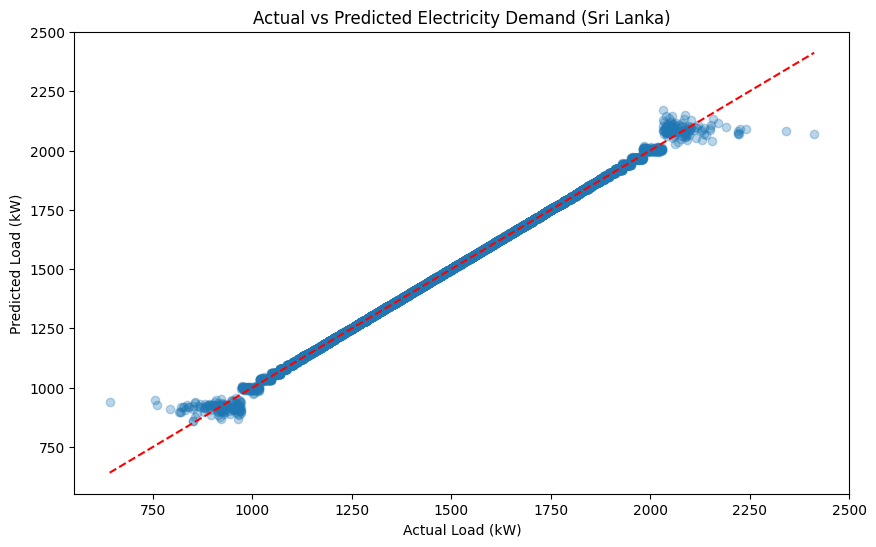

In [6]:
# Predictions
preds = model.predict(X_test_scaled)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"Test RMSE: {rmse:.2f} kW")
print(f"Test R2 Score: {r2:.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(10,6))
plt.scatter(y_test, preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Load (kW)')
plt.ylabel('Predicted Load (kW)')
plt.title('Actual vs Predicted Electricity Demand (Sri Lanka)')
plt.show()